In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import get_validated_data
from src.edit_plot import add_bar_value
from src.format_outputs import print_stadistics
from sklearn.preprocessing import RobustScaler
from datetime import datetime

In [2]:
# Load the validated data
data = get_validated_data()
data.head(5)

,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
0,3057270,Seafarer's Gambit,2024,2024-07-05,Action;Adventure;Indie;RPG;Strategy,Single-player;Family Sharing,3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios
1,3822840,Capitalist Misadventures,2025,2025-07-25,Casual;Indie;Simulation;Strategy,Single-player;Save Anytime;Family Sharing,7.99,0,Caramelo Studios,Caramelo Studios
2,3216640,The Beast and the Princess,2025,2025-06-17,Adventure;Indie;Strategy,Single-player;Steam Achievements;Full controll...,12.99,0,Libragames,Libragames
3,2403620,Air Twister,2023,2023-11-10,Action;Adventure;Indie,Single-player;Steam Achievements;Full controll...,24.99,0,YS Net,ININ
4,1538040,Horde Slayer,2021,2021-03-19,Action;Adventure;Casual;Indie;RPG;Early Access,Single-player;Steam Achievements;Full controll...,3.99,0,Wagner Rodrigues,Wagner Rodrigues


## General analysis
Find problems that need to be fixed before train models

In [3]:
# General information
print(f'\n---Description--- \n{data[['release_date', 'price', 'recommendations']].describe()}')


---Description--- 
                     release_date         price  recommendations
count                       63995  63995.000000     63995.000000
mean   2023-12-10 12:10:47.375576      7.362776       369.666818
min           2021-01-01 00:00:00      0.000000         0.000000
25%           2022-10-25 00:00:00      0.990000         0.000000
50%           2024-03-07 00:00:00      4.990000         0.000000
75%           2025-03-04 00:00:00      9.990000         0.000000
max           2025-12-31 00:00:00   1900.000000    862487.000000
std                           NaN     17.078056      7018.511212



Release Date Analysis
Count of days with releases:     1825
Count of days with above-average releases: 781
Mean:    35
Mode:     17
Median:  31
Max:   150
Min:   1



C:\Users\Alber\AppData\Local\Temp\ipykernel_110252\4097559555.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  years_plot = sns.barplot(x=release_years_count.index, y=release_years_count.values, ax=axes[0, 0], palette='Dark2')
C:\Users\Alber\AppData\Local\Temp\ipykernel_110252\4097559555.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  months_plot = sns.barplot(x = releases_per_month.index, y = releases_per_month.values, ax=axes[0, 1], palette='dark')
C:\Users\Alber\AppData\Local\Temp\ipykernel_110252\4097559555.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May

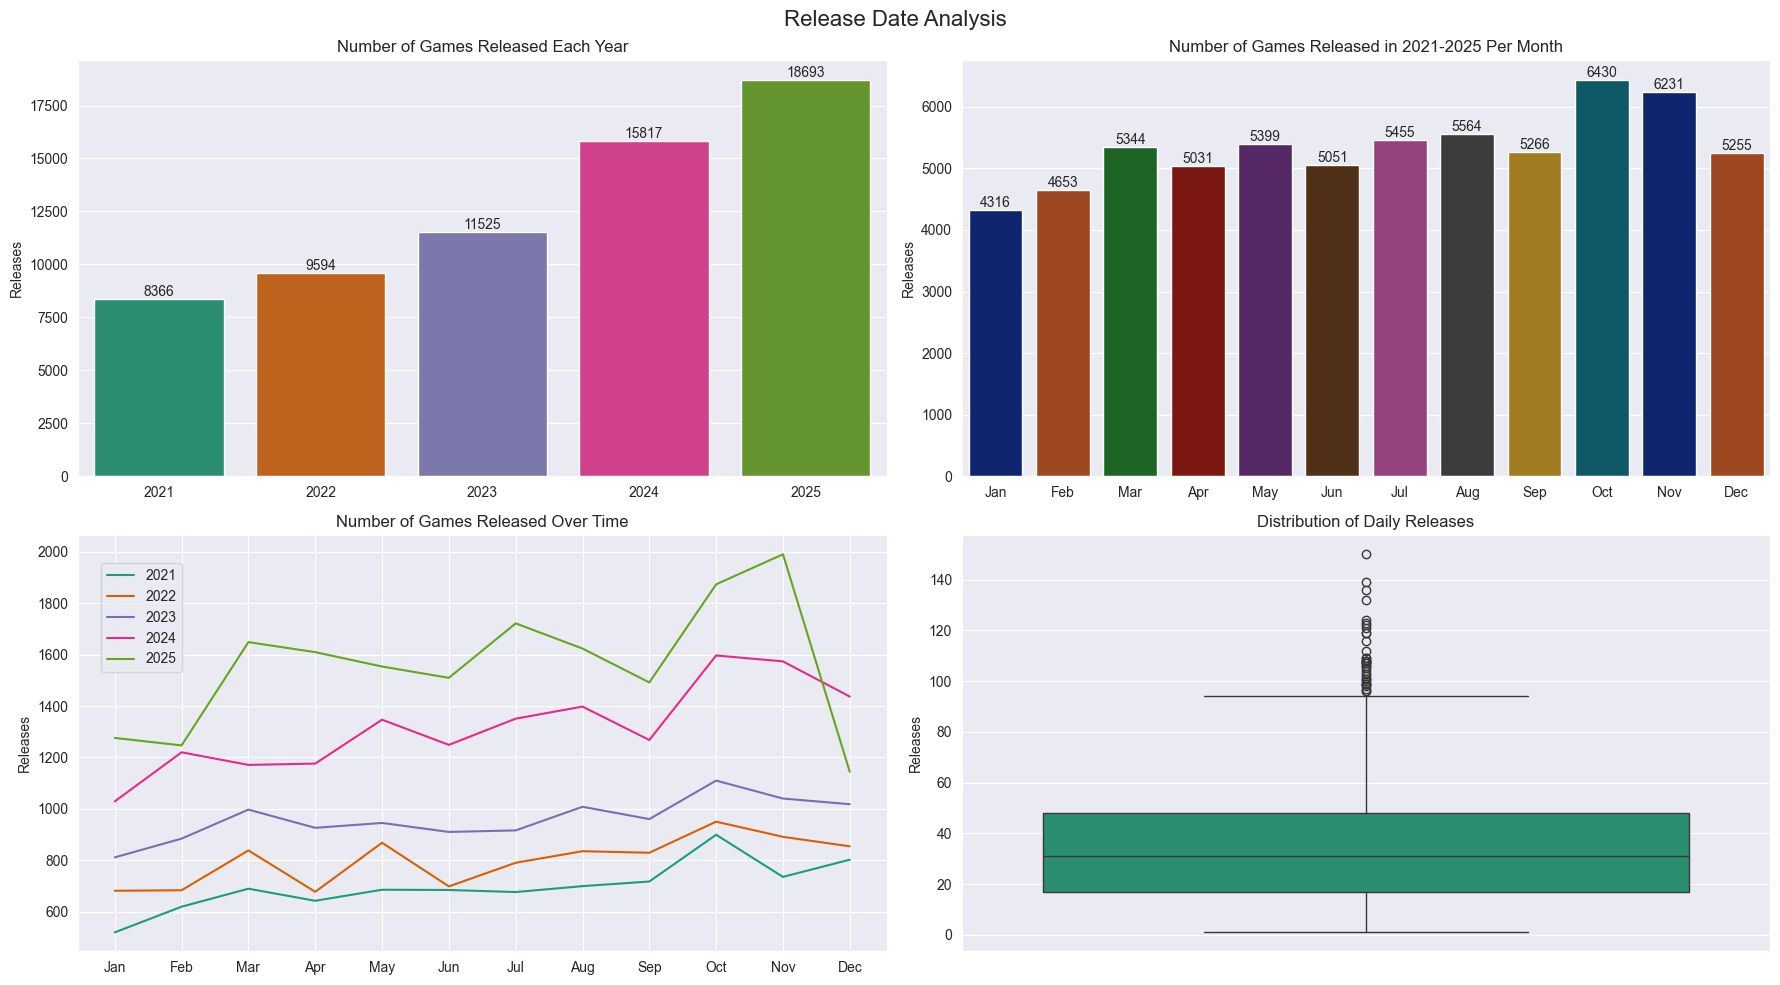

In [4]:
# Release date analysis
release_years_count = data["release_year"].value_counts()
release_dates = data["release_date"].value_counts()
mean, mode, median, max_date, min_date = (
    release_dates.mean(),
    release_dates.mode()[0],
    release_dates.median(),
    release_dates.max(),
    release_dates.min(),
)
popular_release_dates = release_dates[release_dates > mean].count()
releases_per_month = data["release_date"].dt.month.value_counts()
releases_per_year_month = data.groupby(['release_year', data['release_date'].dt.month]).size().reset_index(name='count')
release_date_analysis = f"""
Release Date Analysis
================================================
Count of days with releases:     {release_dates.count()}
Count of days with above-average releases: {popular_release_dates}
Mean:    {mean:.0f}
Mode:     {mode}
Median:  {median:.0f}
Max:   {max_date}
Min:   {min_date}
"""
print(release_date_analysis)

# Visual Release date analysis
sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Release Date Analysis', fontsize=16)

years_plot = sns.barplot(x=release_years_count.index, y=release_years_count.values, ax=axes[0, 0], palette='Dark2')
axes[0,0].set_title('Number of Games Released Each Year')
axes[0,0].set(xlabel=None, ylabel='Releases')
add_bar_value(years_plot)

months_plot = sns.barplot(x = releases_per_month.index, y = releases_per_month.values, ax=axes[0, 1], palette='dark')
axes[0,1].set_title('Number of Games Released in 2021-2025 Per Month')
axes[0,1].set(xlabel=None, ylabel='Releases')
axes[0,1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
add_bar_value(months_plot)

sns.lineplot(data = releases_per_year_month, x = 'release_date', y = 'count', hue='release_year', ax=axes[1, 0], palette='Dark2')
axes[1,0].set_title('Number of Games Released Over Time')
axes[1,0].set(xlabel=None, ylabel='Releases')
axes[1,0].set_xticks(range(1, 13))
axes[1,0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1,0].legend(bbox_to_anchor=(0.02, 0.95), loc='upper left')
plt.tight_layout()

sns.boxplot(release_dates.values, ax=axes[1, 1], palette='Dark2')
axes[1,1].set(xlabel=None, ylabel='Releases')
axes[1,1].set_title('Distribution of Daily Releases')

plt.show()


Genres Combination Analysis
Combinations Count:   1693
Combinations Mean:    33
Combinations Mode:    1
Combinations Median:  3
Combinations Max:     4079
Combinations Min:     1
Genres Analysis
Genres Count:    22
Genres Mean:     8063
Genres Mode:     3
Genres Median:   1754
Genres Max:      43383
Genres Min:      1



C:\Users\Alber\AppData\Local\Temp\ipykernel_110252\34501225.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  popular_genres_combinations_plot = sns.barplot(data= most_popular_genres_combinations, x='count', y='genres', ax=axes[0,0], palette='Dark2')
C:\Users\Alber\AppData\Local\Temp\ipykernel_110252\34501225.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  popular_genres_plot = sns.barplot(x=most_popular_genres.values, y=most_popular_genres.index, ax=axes[1,0], palette='Dark2')
C:\Users\Alber\AppData\Local\Temp\ipykernel_110252\34501225.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data = genres_count.values, ax=axes[1, 1], palette='Dark2')


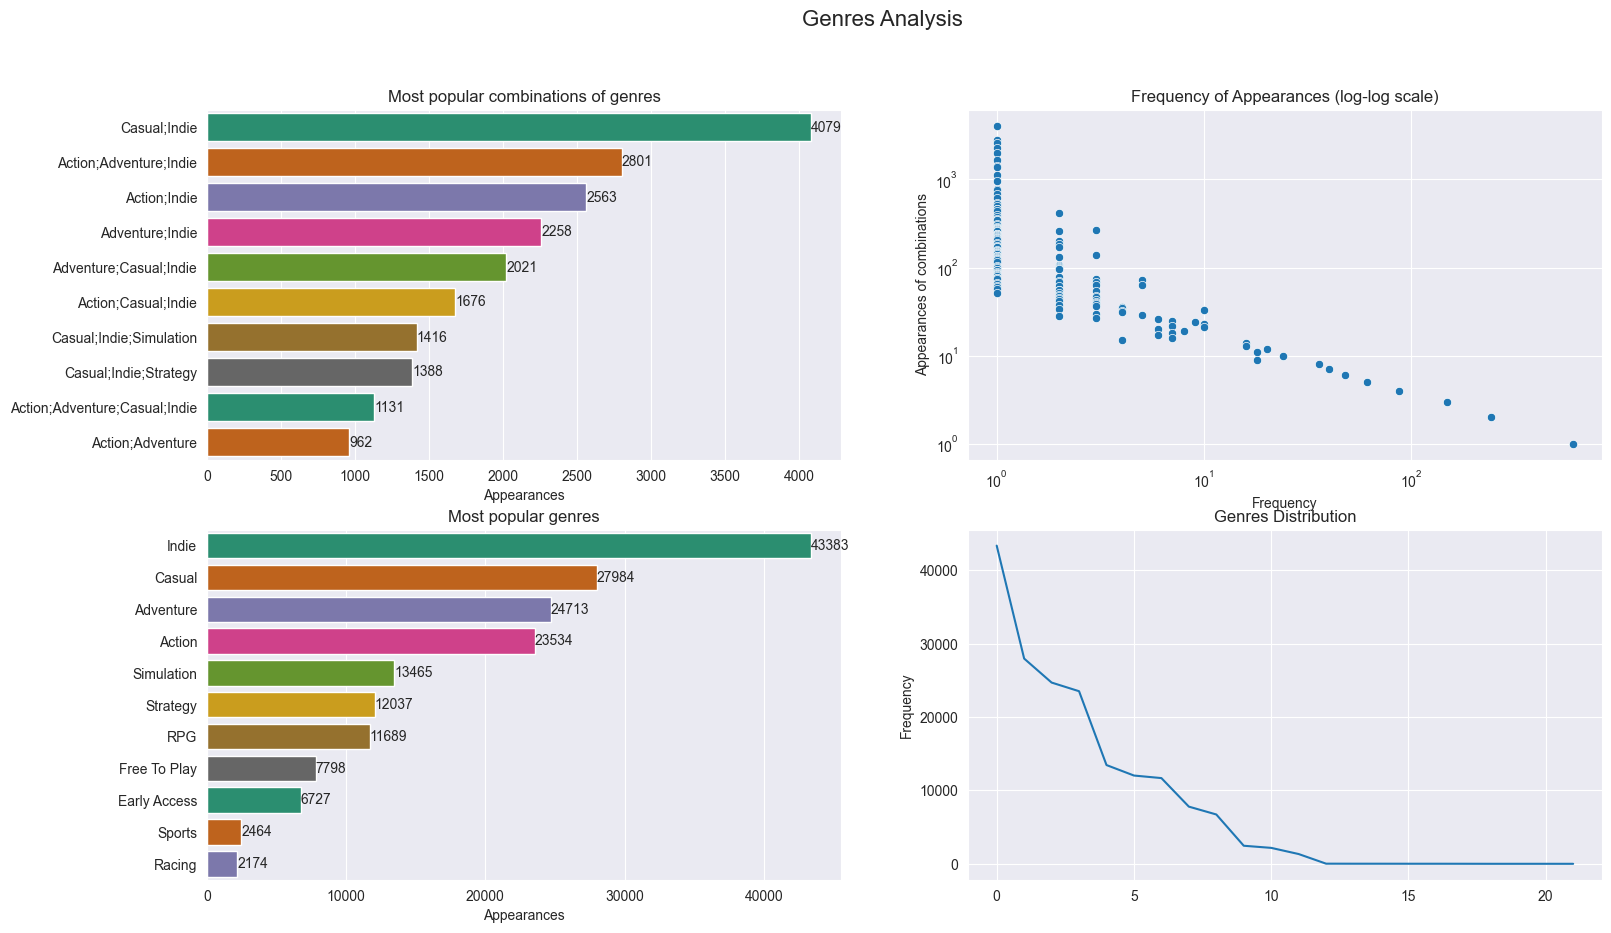

In [5]:
# Genres analysis
splitted_genres = data['genres'].str.split(';')
splitted_genres = splitted_genres[splitted_genres.str.len() > 1]
genres_combinations = splitted_genres.value_counts().reset_index(name='count')

most_popular_genres_combinations = genres_combinations.head(10) 
most_popular_genres_combinations['genres'] = most_popular_genres_combinations['genres'].str.join(';')

genres_cobinations_count = genres_combinations['count'].value_counts().reset_index(name='frequency')
genres_count = splitted_genres.explode().value_counts()

gencomb_mean, gencomb_mode, gencomb_median, gencomb_max, gencomb_min = (
    genres_combinations['count'].mean(),
    genres_combinations['count'].mode()[0],
    genres_combinations['count'].median(),
    genres_combinations['count'].max(),
    genres_combinations['count'].min(),
)
gen_mean, gen_mode, gen_median, gen_max, gen_min = (
    genres_count.mean(),
    genres_count.mode()[0],
    genres_count.median(),
    genres_count.max(),
    genres_count.min(),
)
most_popular_genres = genres_count[genres_count.values > gen_median]

genres_analysis = f"""
Genres Combination Analysis
================================================
Combinations Count:   {genres_combinations.count().values[1]}
Combinations Mean:    {gencomb_mean:.0f}
Combinations Mode:    {gencomb_mode}
Combinations Median:  {gencomb_median:.0f}
Combinations Max:     {gencomb_max}
Combinations Min:     {gencomb_min}
================================================
Genres Analysis
Genres Count:    {genres_count.count()}
Genres Mean:     {gen_mean:.0f}
Genres Mode:     {gen_mode}
Genres Median:   {gen_median:.0f}
Genres Max:      {gen_max}
Genres Min:      {gen_min}
"""
print(genres_analysis)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Genres Analysis', fontsize=16)

popular_genres_combinations_plot = sns.barplot(data= most_popular_genres_combinations, x='count', y='genres', ax=axes[0,0], palette='Dark2')
axes[0,0].set_title('Most popular combinations of genres')
axes[0,0].set(xlabel='Appearances', ylabel=None)
add_bar_value(popular_genres_combinations_plot)

sns.scatterplot(data = genres_cobinations_count, x = 'frequency', y = 'count', ax=axes[0,1])
axes[0,1].set_title('Frequency of Appearances (log-log scale)')
axes[0,1].set_xscale('log')
axes[0,1].set_yscale('log')
axes[0,1].set(xlabel='Frequency', ylabel='Appearances of combinations')

popular_genres_plot = sns.barplot(x=most_popular_genres.values, y=most_popular_genres.index, ax=axes[1,0], palette='Dark2')
axes[1,0].set_title('Most popular genres')
axes[1,0].set(xlabel='Appearances', ylabel=None)
add_bar_value(popular_genres_plot)

sns.lineplot(data = genres_count.values, ax=axes[1, 1], palette='Dark2')
axes[1,1].set_title('Genres Distribution')
axes[1,1].set(xlabel=None, ylabel='Frequency')

plt.show()



Categories Combination Analysis
Combinations Count:   7692
Combinations Mean:    8
Combinations Mode:    1
Combinations Median:  1
Combinations Max:     14727
Combinations Min:     1
Categories Analysis
Categories Count:    54
Categories Mean:     5009
Categories Mode:     26
Categories Median:   1716
Categories Max:      58346
Categories Min:      7



C:\Users\Alber\AppData\Local\Temp\ipykernel_110252\2281526414.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  popular_categories_combinations_plot = sns.barplot(data= most_popular_categories_combinations, x='count', y='categories', ax=axes[0], palette='Dark2')


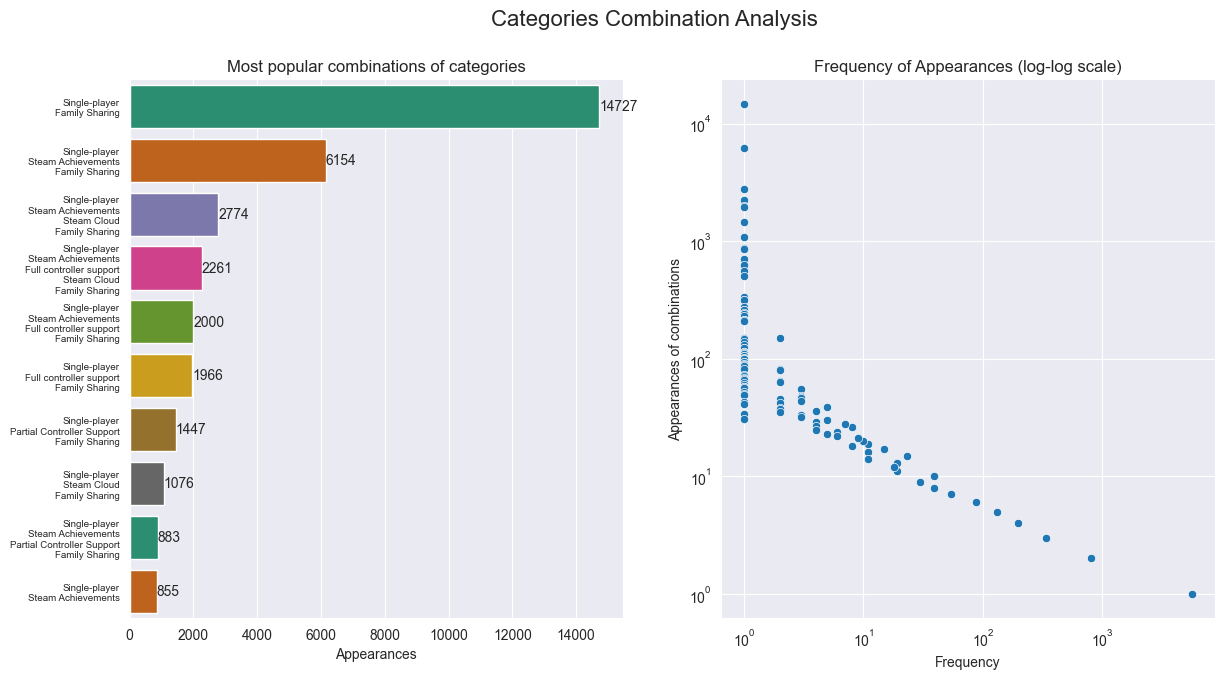

C:\Users\Alber\AppData\Local\Temp\ipykernel_110252\2281526414.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  popular_categories_plot = sns.barplot(x=most_popular_categories.values, y=most_popular_categories.index, ax=axes[0], palette='Dark2')
C:\Users\Alber\AppData\Local\Temp\ipykernel_110252\2281526414.py:77: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data = categories_count.values, ax=axes[1], palette='Dark2')


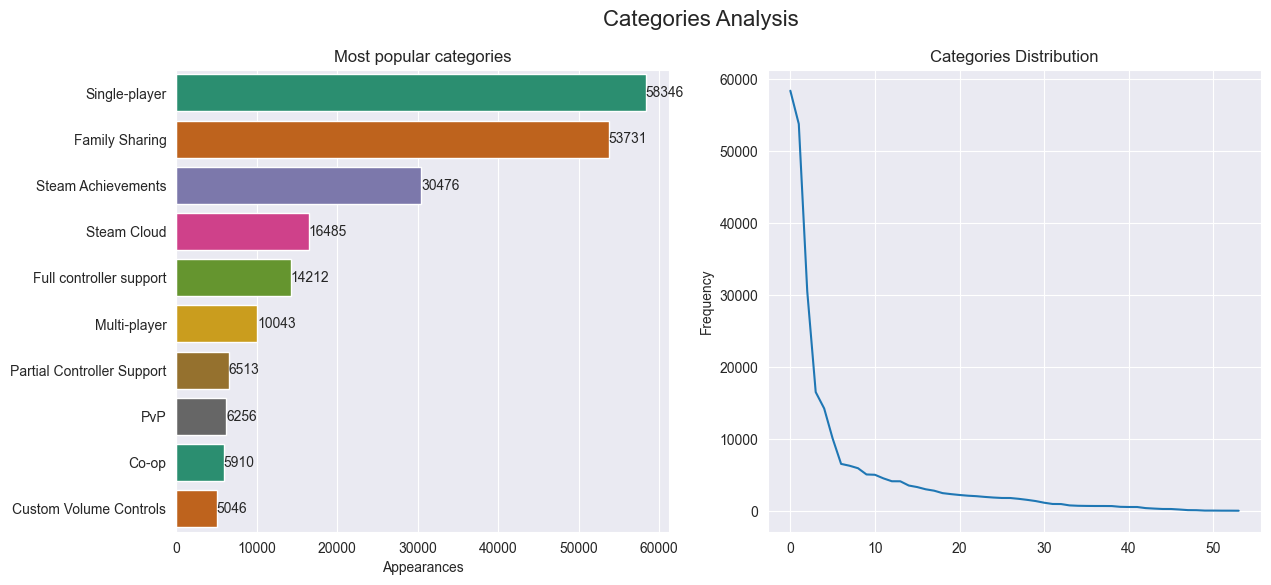

In [6]:
# Popular analysis
splitted_categories = data['categories'].str.split(';')
splitted_categories = splitted_categories[splitted_categories.str.len() > 1]
popular_categories_combination = splitted_categories.value_counts().reset_index(name='count')

most_popular_categories_combinations = popular_categories_combination.head(10)
most_popular_categories_combinations['categories'] = most_popular_categories_combinations['categories'].str.join(';')
most_popular_categories_combinations['categories'] = most_popular_categories_combinations['categories'].apply(
    lambda x: "\n".join(x.split(";"))
)
categories_cobinations_count = popular_categories_combination['count'].value_counts().reset_index(name='frequency')
categories_count = splitted_categories.explode().value_counts()


catcomb_mean, catcomb_mode, catcomb_median, catcomb_max, catcomb_min = (
    popular_categories_combination['count'].mean(),
    popular_categories_combination['count'].mode()[0],
    popular_categories_combination['count'].median(),
    popular_categories_combination['count'].max(),
    popular_categories_combination['count'].min(),
)
cat_mean, cat_mode, cat_median, cat_max, cat_min = (
    categories_count.mean(),
    categories_count.mode()[0],
    categories_count.median(),
    categories_count.max(),
    categories_count.min(),
)
most_popular_categories = categories_count[categories_count.values > cat_mean]

categories_analysis = f"""
Categories Combination Analysis
================================================
Combinations Count:   {popular_categories_combination.shape[0]}
Combinations Mean:    {catcomb_mean:.0f}
Combinations Mode:    {catcomb_mode}
Combinations Median:  {catcomb_median:.0f}
Combinations Max:     {catcomb_max}
Combinations Min:     {catcomb_min}
================================================
Categories Analysis
Categories Count:    {categories_count.shape[0]}
Categories Mean:     {cat_mean:.0f}
Categories Mode:     {cat_mode}
Categories Median:   {cat_median:.0f}
Categories Max:      {cat_max}
Categories Min:      {cat_min}
"""
print(categories_analysis)

# Categories Combination Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Categories Combination Analysis', fontsize=16)

popular_categories_combinations_plot = sns.barplot(data= most_popular_categories_combinations, x='count', y='categories', ax=axes[0], palette='Dark2')
axes[0].set_title('Most popular combinations of categories')
axes[0].set(xlabel='Appearances', ylabel=None)
add_bar_value(popular_categories_combinations_plot)
axes[0].tick_params(axis='y', labelsize=7)

sns.scatterplot(data = categories_cobinations_count, x = 'frequency', y = 'count', ax=axes[1])
axes[1].set_title('Frequency of Appearances (log-log scale)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set(xlabel='Frequency', ylabel='Appearances of combinations')
plt.show()

# Categories Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Categories Analysis', fontsize=16)

popular_categories_plot = sns.barplot(x=most_popular_categories.values, y=most_popular_categories.index, ax=axes[0], palette='Dark2')
axes[0].set_title('Most popular categories')
axes[0].set(xlabel='Appearances', ylabel=None)
add_bar_value(popular_categories_plot)

sns.lineplot(data = categories_count.values, ax=axes[1], palette='Dark2')
axes[1].set_title('Categories Distribution')
axes[1].set(xlabel=None, ylabel='Frequency')
plt.show()


In [ ]:
# Test One-Hot Encoding to analyze the correlation between categories and recommendations
one_hot_encoding = data[['release_year', 'release_date','price', 'recommendations']]
one_hot_categories = data['categories'].str.get_dummies(';')
one_hot_genres = data['genres'].str.get_dummies(';')
one_hot_encoding = pd.concat([one_hot_encoding, one_hot_genres, one_hot_categories], axis=1)
correlations = one_hot_encoding.corr()
strong_corr = (
    correlations.where(np.triu(np.ones(correlations.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
)

print(strong_corr[abs(strong_corr) > 0.6])


release_year                release_date                    0.979502
Remote Play on Phone        Remote Play on Tablet           0.939067
Free To Play                Family Sharing                 -0.845873
Online PvP                  PvP                             0.834882
Co-op                       Online Co-op                    0.818591
Remote Play Together        Shared/Split Screen             0.807881
Shared/Split Screen         Shared/Split Screen PvP         0.782018
Multi-player                PvP                             0.761829
Tracked Controller Support  VR Only                         0.753274
Shared/Split Screen         Shared/Split Screen Co-op       0.750816
Co-op                       Multi-player                    0.737455
Custom Volume Controls      Playable without Timed Input    0.721831
Multi-player                Online PvP                      0.636828
Massively Multiplayer       MMO                             0.636138
Remote Play Together        Shared

In [8]:
# recommendations
recommendations_count = data['recommendations'].value_counts()
print(f'Recommendations count equal to 0: {recommendations_count.head(1).values[0]}')
print(f'Recommendations count equal to 1: {recommendations_count[recommendations_count == 1].shape[0]}')
print(f'Recommendations mode: {recommendations_count.mode()[0]}')
print(f'Recommendations median: {recommendations_count.median()}')
print(f'Recommendations higher than 10: {recommendations_count[recommendations_count > 10].shape[0]}')

Recommendations count equal to 0: 56045
Recommendations count equal to 1: 1555
Recommendations mode: 1
Recommendations median: 1.0
Recommendations higher than 10: 161


In [9]:
# developer and publisher
developer_is_developer = data['developer'] == data['publisher']
developer_count = data['developer'].value_counts().head(10)
publisher_count = data['publisher'].value_counts().head(10)
print(f'Number of games where developer is publisher: {developer_is_developer.sum()}')
display(f'\nTop 10 developers: {developer_count}')
display(f'\nTop 10 publishers: {publisher_count}')

Number of games where developer is publisher: 46975


"\nTop 10 developers: developer\nEroticGamesClub          215\nBully Revenge Studios    119\nGamesforgames             96\nDo Games Limited          90\nArchor Wright             88\nKing Kong                 87\nCyber Keks                85\nBoogygames Studios        83\nCute Hannah's Games       72\nFollow the fun            72\nName: count, dtype: int64"

'\nTop 10 publishers: publisher\nEroticGamesClub                    215\nUnknown                            173\nBFG Entertainment                  172\n8floor                             150\nHede                               142\nBully Revenge Studios              119\nKagura Games                       119\nDigiPen Institute of Technology    100\nGamesforgames                       98\nindie.io                            95\nName: count, dtype: int64'

## Visualization of the general analysis findings

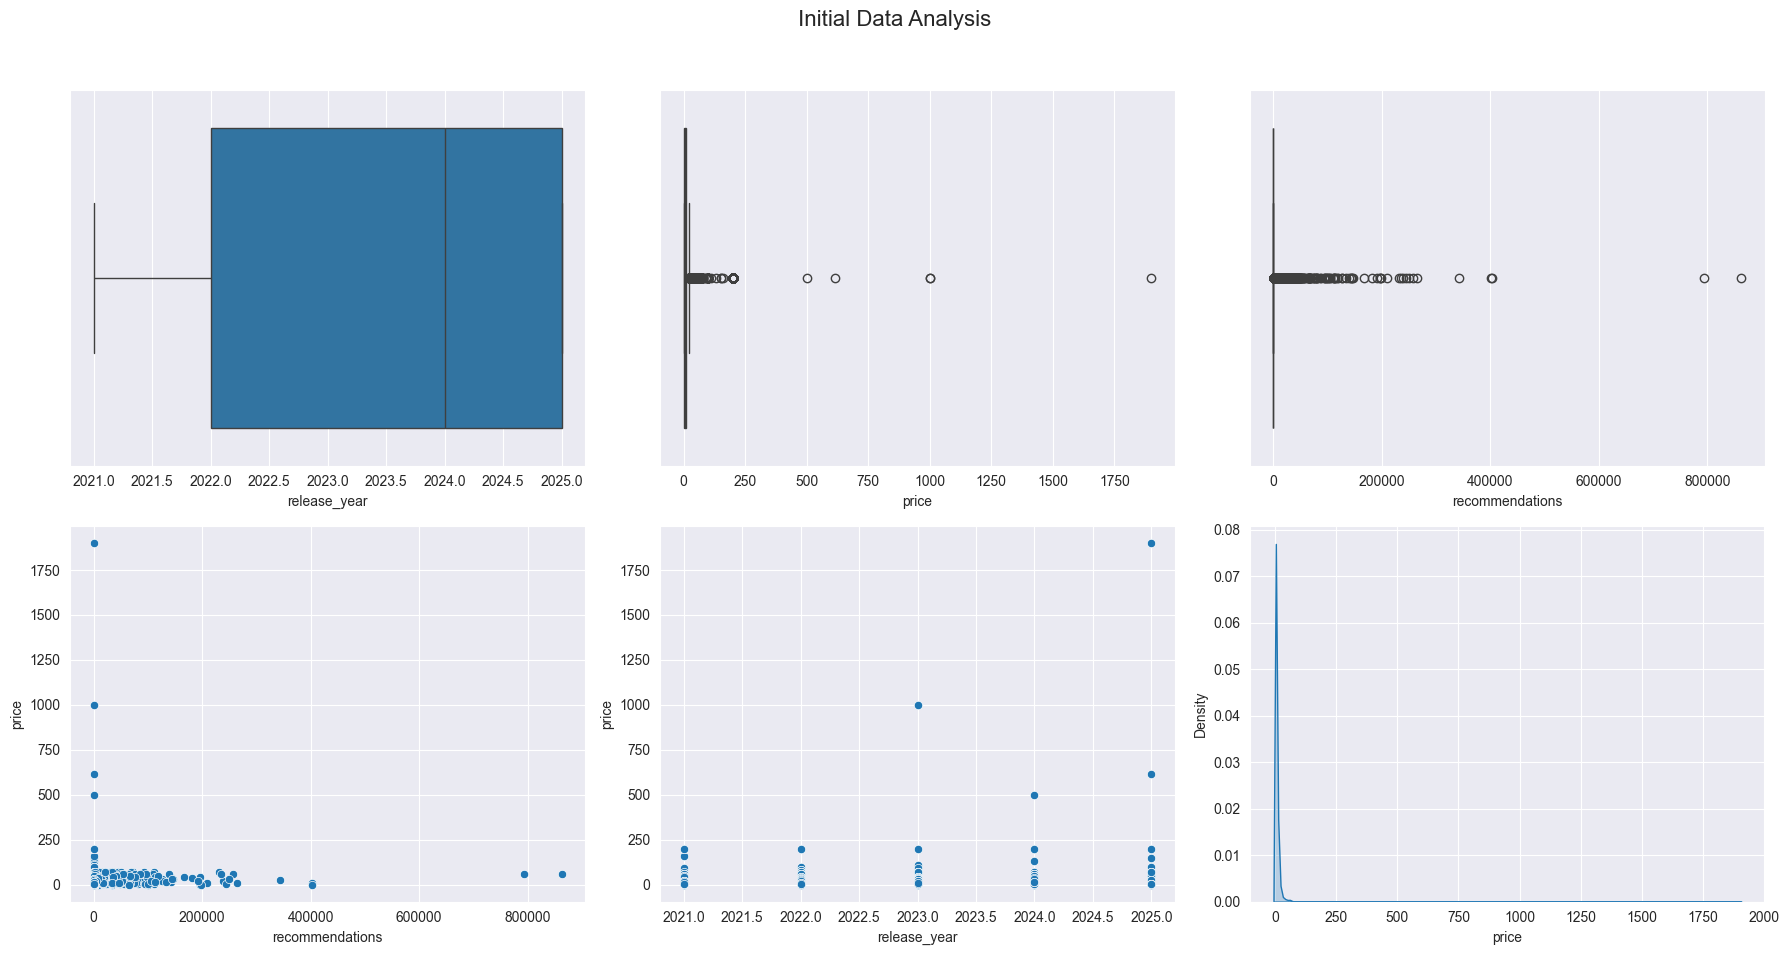

In [10]:
# Generate visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Initial Data Analysis', fontsize=16)
 
sns.boxplot(x=data['release_year'], ax=axes[0, 0])
sns.boxplot(x=data['price'], ax=axes[0, 1])
sns.boxplot(x=data['recommendations'], ax=axes[0, 2])
 
sns.scatterplot(data=data, x='recommendations', y='price', ax=axes[1, 0])
sns.scatterplot(data=data, x='release_year', y='price', ax=axes[1, 1])
 
sns.kdeplot(data=data, x='price', fill=True, ax=axes[1, 2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Advanced Exploratory Data Analysis

In [11]:
data_test = data.copy()

Correlation matrix: 
                    appid  release_year     price  recommendations
appid            1.000000      0.822193 -0.049377        -0.037159
release_year     0.822193      1.000000  0.013420        -0.008288
price           -0.049377      0.013420  1.000000         0.060516
recommendations -0.037159     -0.008288  0.060516         1.000000


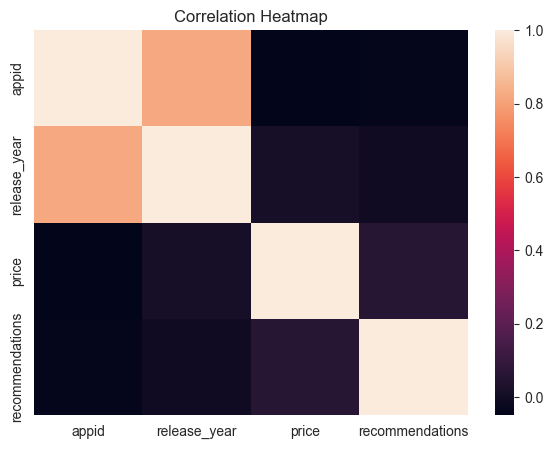

In [12]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
plt.title('Correlation Heatmap')
sns.heatmap(data.corr(numeric_only=True))
print(f'Correlation matrix: \n{data.corr(numeric_only=True)}')

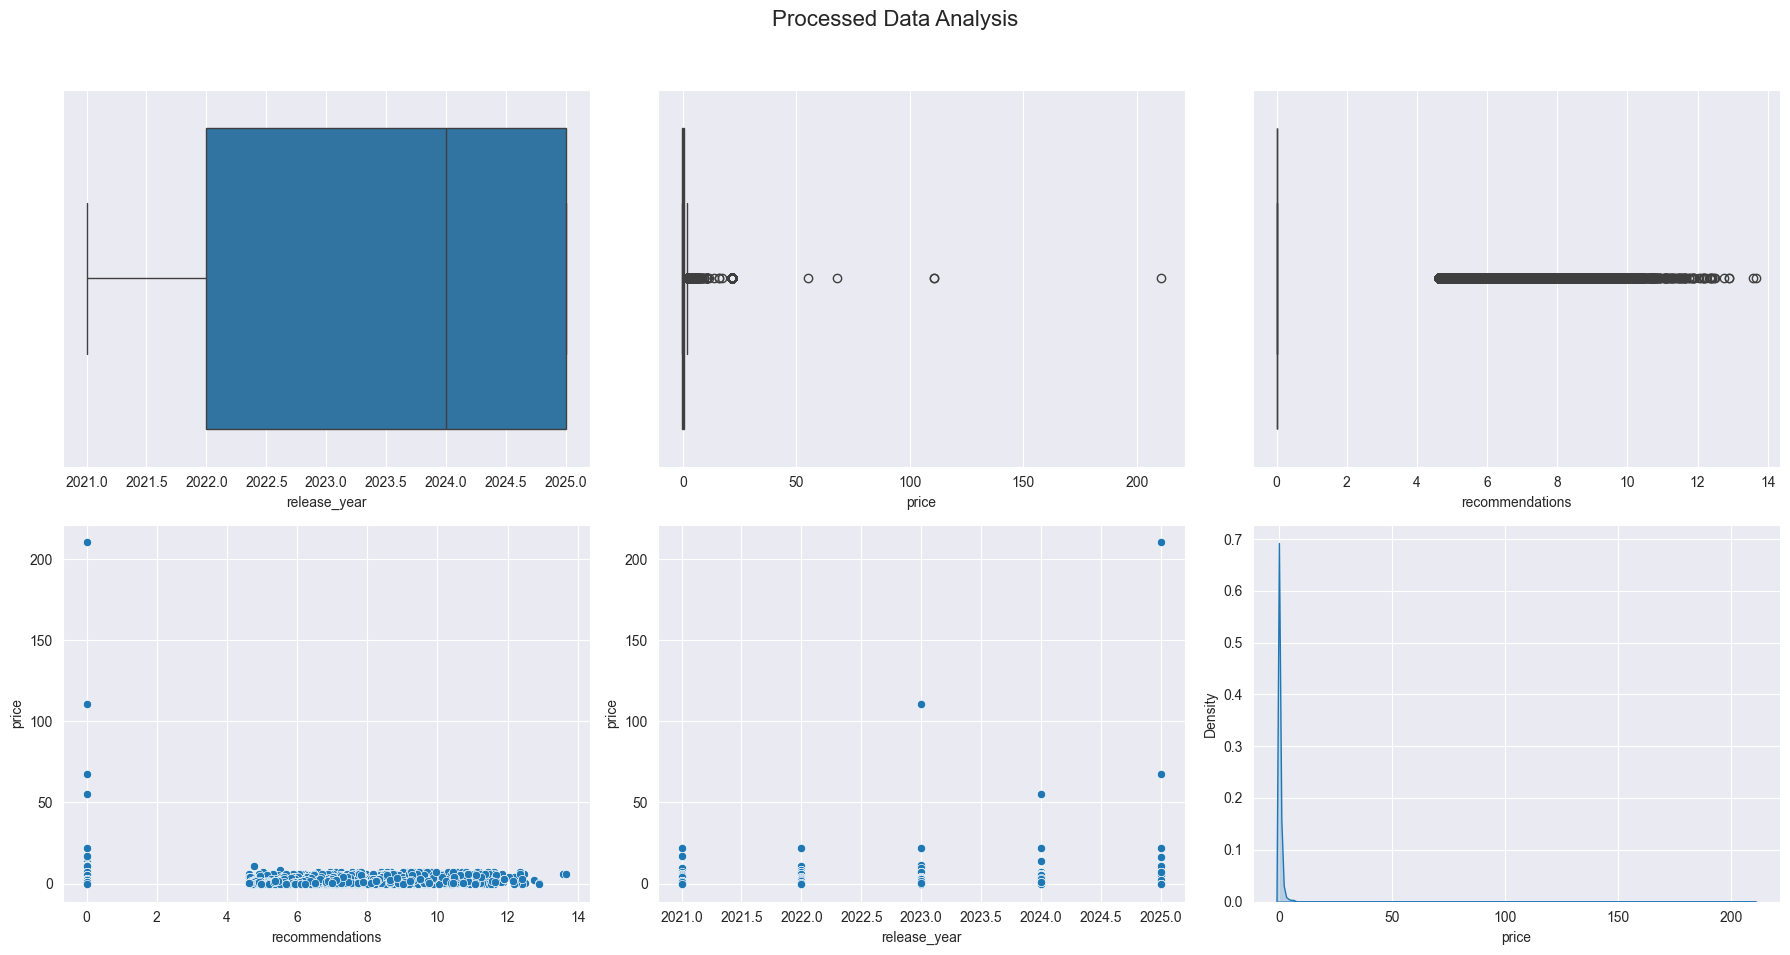

In [13]:
# Test methods to minimize the impact of outliers on recommendations and price. 
scaler = RobustScaler() 
data_test['recommendations'] = np.log1p(data_test['recommendations']) 
data_test[['price', 'recommendations']] = scaler.fit_transform(data_test[['price', 'recommendations']])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Processed Data Analysis', fontsize=16)
 
sns.boxplot(x=data_test['release_year'], ax=axes[0, 0])
sns.boxplot(x=data_test['price'], ax=axes[0, 1])
sns.boxplot(x=data_test['recommendations'], ax=axes[0, 2])
 
sns.scatterplot(data=data_test, x='recommendations', y='price', ax=axes[1, 0])
sns.scatterplot(data=data_test, x='release_year', y='price', ax=axes[1, 1])
 
sns.kdeplot(data=data_test, x='price', fill=True, ax=axes[1, 2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

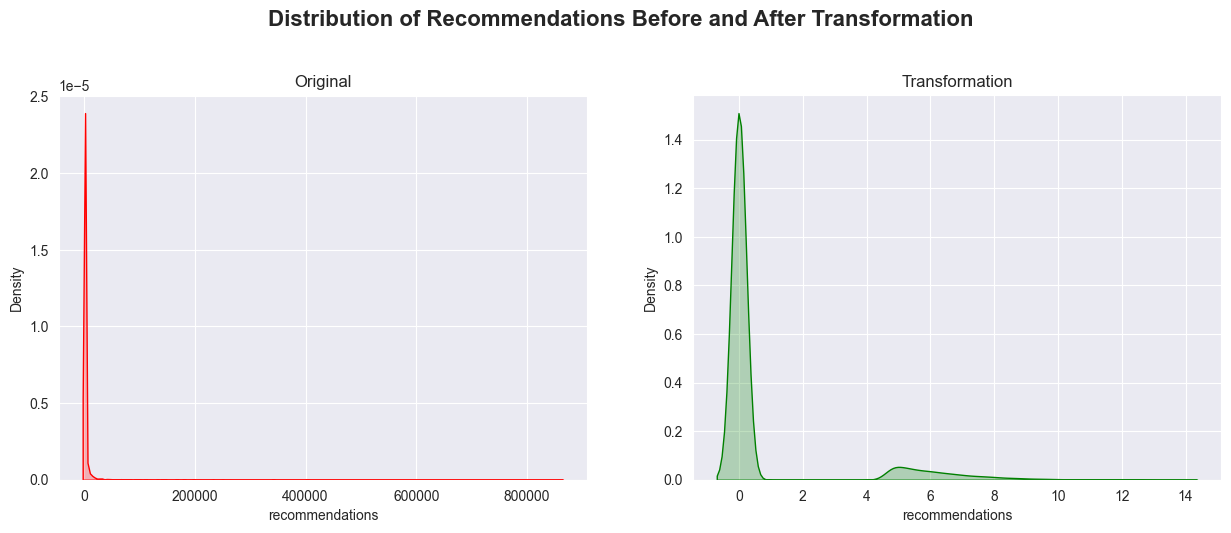

In [14]:
# Visualize the distribution of recommendations before and after the transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 
fig.suptitle('Distribution of Recommendations Before and After Transformation', fontsize=16, fontweight='bold', y=1.05)

sns.kdeplot(data['recommendations'], ax=axes[0], fill=True, color="red")
axes[0].set_title("Original")
 
sns.kdeplot(data_test['recommendations'], ax=axes[1], fill=True, color="green")
axes[1].set_title("Transformation")

plt.show()

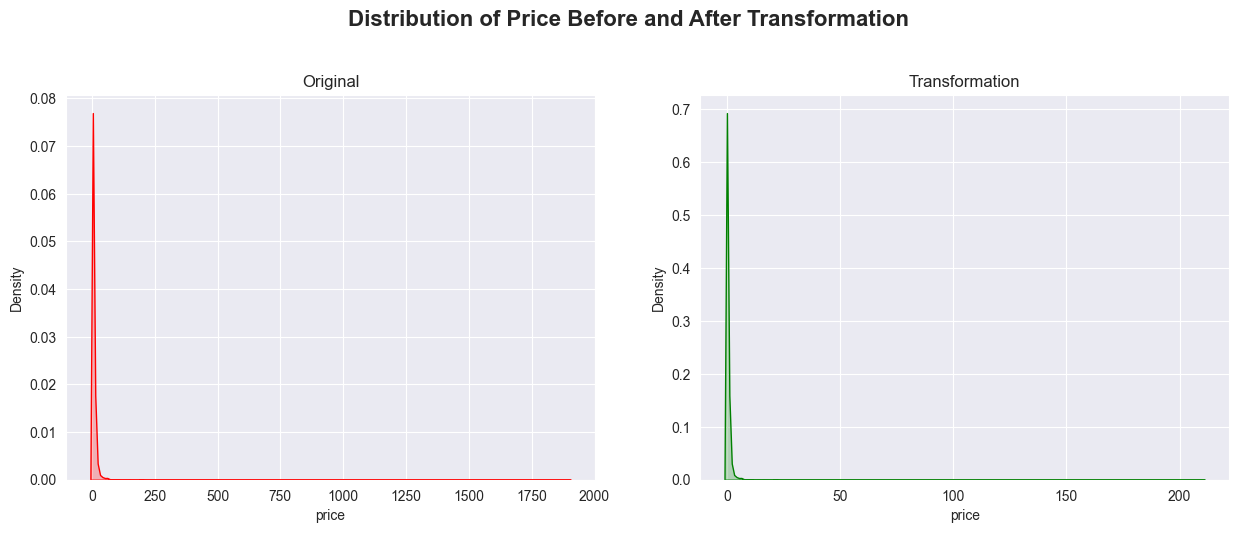

In [15]:
# Visualize the distribution of price before and after the transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 
fig.suptitle('Distribution of Price Before and After Transformation', fontsize=16, fontweight='bold', y=1.05)

sns.kdeplot(data['price'], ax=axes[0], fill=True, color="red")
axes[0].set_title("Original")
 
sns.kdeplot(data_test['price'], ax=axes[1], fill=True, color="green")
axes[1].set_title("Transformation")

plt.show()

<Axes: xlabel='release_time', ylabel='recommendations'>

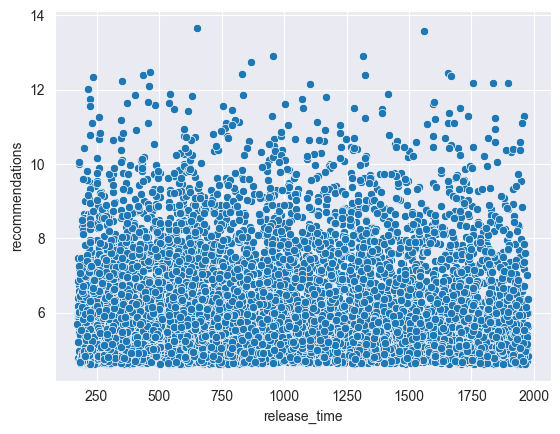

In [16]:
# Relation between release time and popularity (recommendations) 
today = datetime.now()
data_test['release_time'] = (today - data_test['release_date']).dt.days 
popular_games = data_test['recommendations'] != 0
sns.scatterplot(data=data_test[popular_games], x='release_time', y='recommendations') 

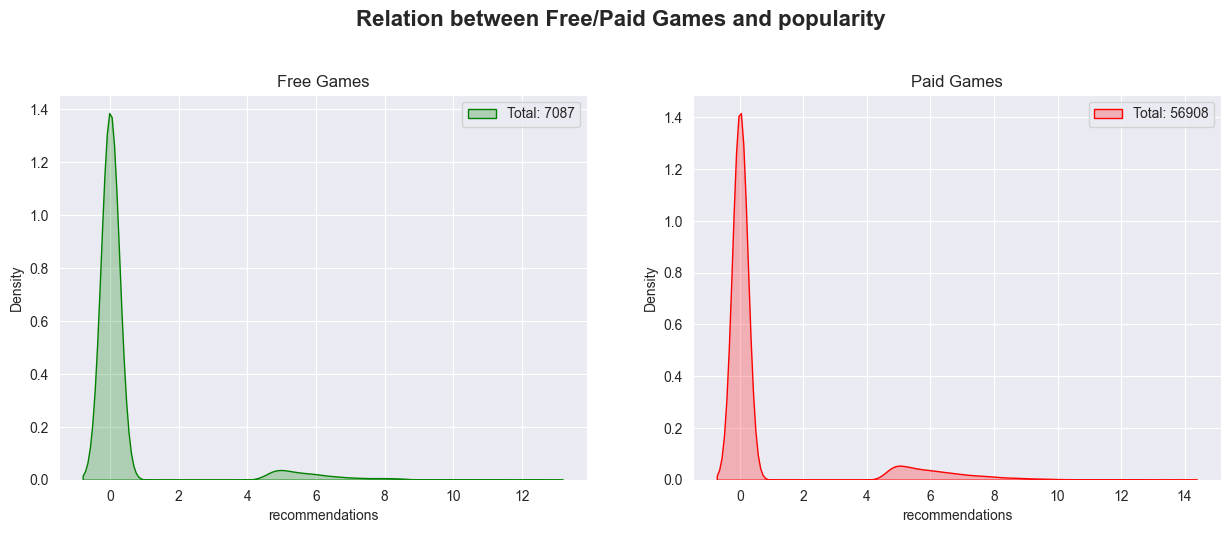

In [17]:
# Relation between Free/Paid Games popularity   
f2p = data_test['price'] == 0 
free_games = data_test[f2p]
paid_games = data_test[~f2p]


fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 
fig.suptitle('Relation between Free/Paid Games and popularity', fontsize=16, fontweight='bold', y=1.05)

sns.kdeplot(free_games['recommendations'], ax=axes[0], fill=True, color="green", label=f"Total: {len(free_games)}")
axes[0].set_title("Free Games")
axes[0].legend()
 
sns.kdeplot(paid_games['recommendations'], ax=axes[1], fill=True, color="red", label=f"Total: {len(paid_games)}")
axes[1].set_title("Paid Games") 
axes[1].legend()

plt.show()

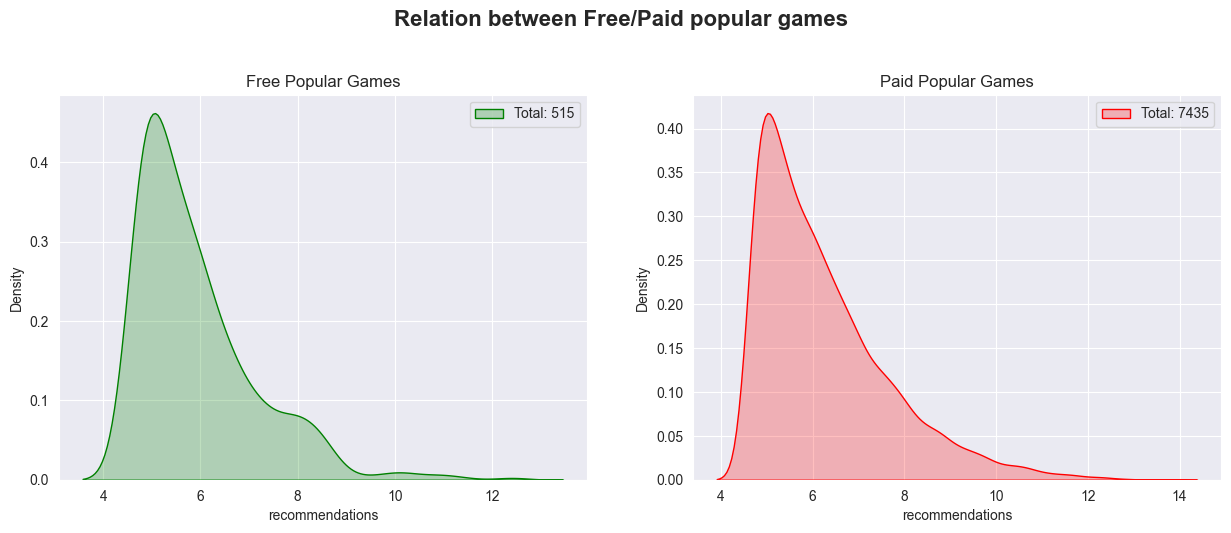

In [18]:
# Relation between Free/Paid popular games   
popular_games = data_test['recommendations'] > 0
free_popular_games = data_test[f2p & popular_games] 
paid_popular_games = data_test[~f2p & popular_games]

fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 
fig.suptitle('Relation between Free/Paid popular games', fontsize=16, fontweight='bold', y=1.05)

sns.kdeplot(free_popular_games['recommendations'], ax=axes[0], fill=True, color="green", label=f"Total: {len(free_popular_games)}")
axes[0].set_title("Free Popular Games")
axes[0].legend()
 
sns.kdeplot(paid_popular_games['recommendations'], ax=axes[1], fill=True, color="red", label=f"Total: {len(paid_popular_games)}")
axes[1].set_title("Paid Popular Games") 
axes[1].legend()

plt.show()

In [19]:
# Insights during covid period  
Pandemic = (data['release_date'] >= '2020-03-11') & (data['release_date'] <= '2023-05-05')
No_Pandemic_= ~Pandemic  
print(f'Average price during the pandemic: {data[Pandemic]["price"].mean()}')
print(f'Average price outside the pandemic: {data[No_Pandemic_]["price"].mean()}')
print(f'Average recommendations during the pandemic: {data[Pandemic]["recommendations"].mean()}')
print(f'Average recommendations outside the pandemic: {data[No_Pandemic_]["recommendations"].mean()}')

Average price during the pandemic: 6.936965662871833
Average price outside the pandemic: 7.582524934258841
Average recommendations during the pandemic: 432.45381931692987
Average recommendations outside the pandemic: 337.2640780839118
